In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

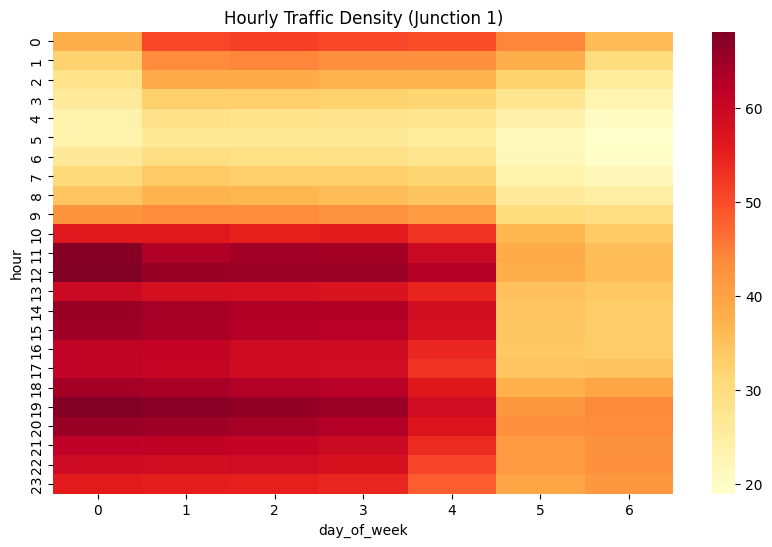

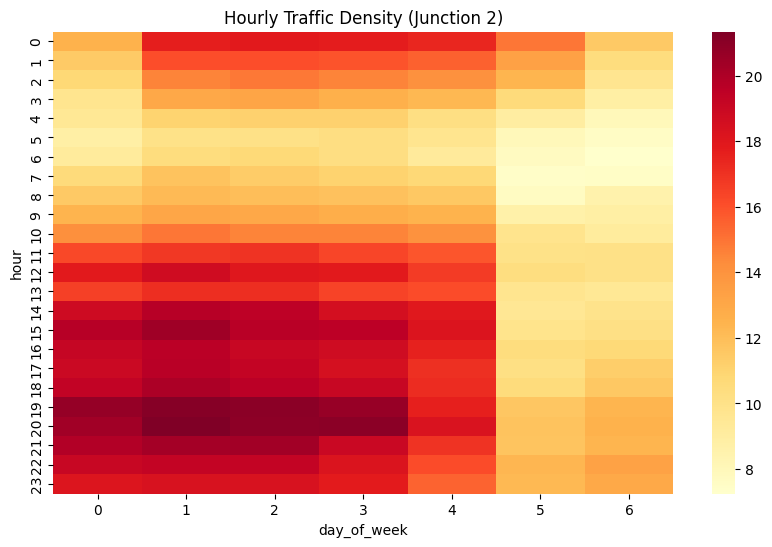

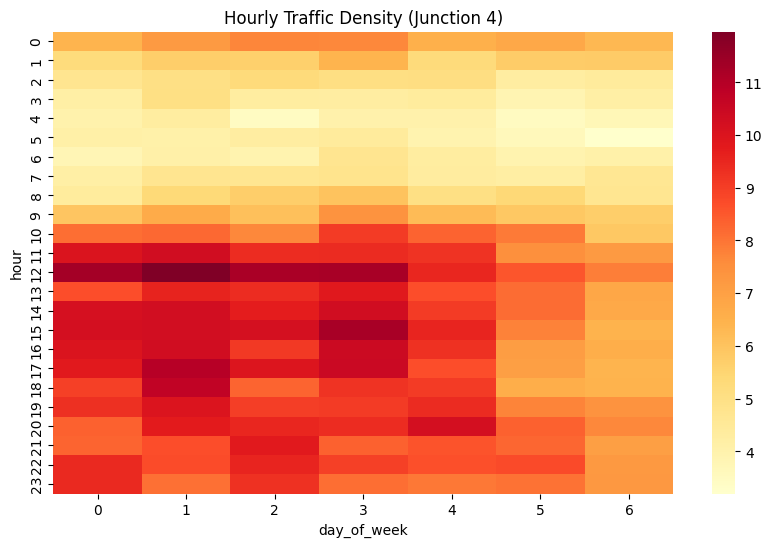

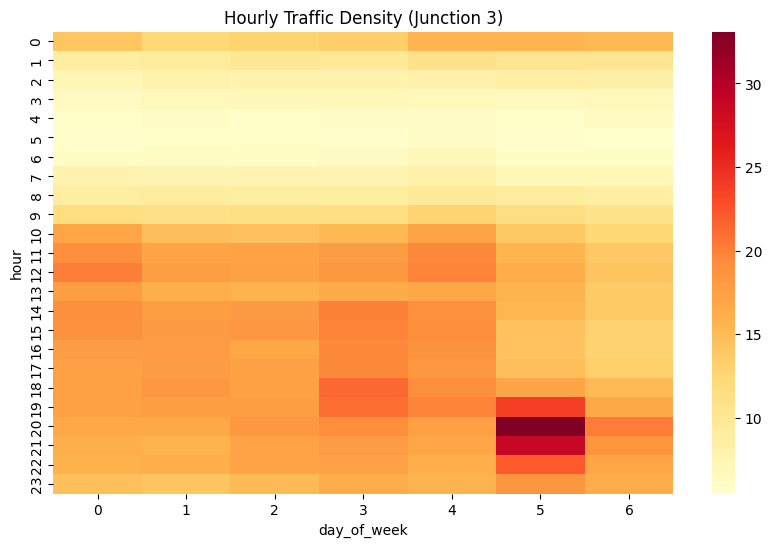

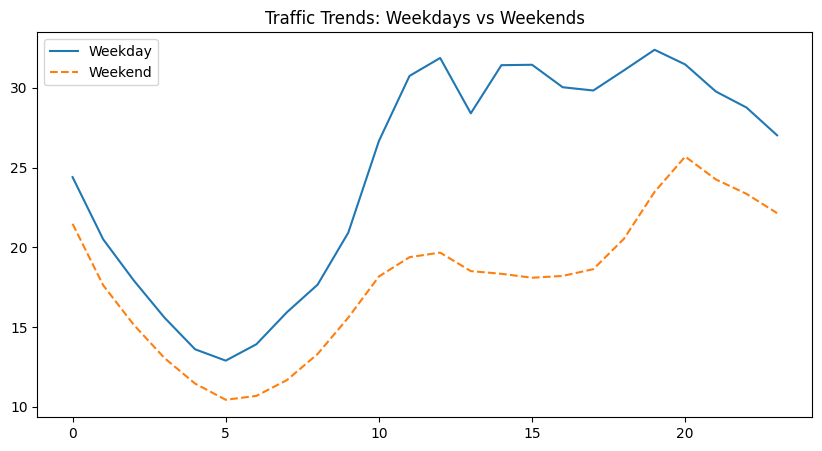

In [24]:
# Load Data
df = pd.read_csv('Processed_Traffic_Data_bhavyaVerma.csv')
df['DateTime'] = pd.to_datetime(df['time_obj'])

# Calculate Average Vehicle Count (Metric for Congestion)
hourly_stats = df.groupby(['Junction', 'hour'])['Vehicles'].agg(['mean', 'std']).reset_index()
hourly_stats.rename(columns={'mean': 'Avg_Vehicles', 'std': 'Std_Vehicles'}, inplace=True)

# Identify Peak Hours
# Statistical threshold: Mean + 1 Standard Deviation
global_threshold = df['Vehicles'].mean() + df['Vehicles'].std()
peak_hours = hourly_stats[hourly_stats['Avg_Vehicles'] > global_threshold]

# Examine Temporal Patterns (Weekday vs Weekend)
weekly_patterns = df.groupby(['is_weekend', 'hour'])['Vehicles'].mean().unstack(level=0)

# Analyze Influencing Factors (Correlation)
corr_matrix = df[['Vehicles', 'Rain', 'Temp Max', 'Temp Min']].corr()

# Create Visualizations
# Heatmap of Junction 1
pivot_j1 = df[df['Junction'] == 1].pivot_table(index='hour', columns='day_of_week', values='Vehicles', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_j1, cmap='YlOrRd')
plt.title('Hourly Traffic Density (Junction 1)')
plt.savefig('traffic_heatmap1.png')

# Heatmap of Junction 2
pivot_j1 = df[df['Junction'] == 2].pivot_table(index='hour', columns='day_of_week', values='Vehicles', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_j1, cmap='YlOrRd')
plt.title('Hourly Traffic Density (Junction 2)')
plt.savefig('traffic_heatmap2.png')

# Heatmap of Junction 4
pivot_j1 = df[df['Junction'] == 4].pivot_table(index='hour', columns='day_of_week', values='Vehicles', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_j1, cmap='YlOrRd')
plt.title('Hourly Traffic Density (Junction 4)')
plt.savefig('traffic_heatmap4.png')

# Heatmap of Junction 3
pivot_j1 = df[df['Junction'] == 3].pivot_table(index='hour', columns='day_of_week', values='Vehicles', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_j1, cmap='YlOrRd')
plt.title('Hourly Traffic Density (Junction 3)')
plt.savefig('traffic_heatmap3.png')

# Weekday vs Weekend Line Chart
plt.figure(figsize=(10, 5))
plt.plot(weekly_patterns.index, weekly_patterns[0], label='Weekday')
plt.plot(weekly_patterns.index, weekly_patterns[1], label='Weekend', linestyle='--')
plt.legend()
plt.title('Traffic Trends: Weekdays vs Weekends')
plt.savefig('weekday_weekend_trends.png')
